# AI-Based Crowd Surveillance & Heatmap Generator
### Task: Crowd Movement Heatmap Generator (QA-Enhanced Version)
**Objective:** Generate dynamic heatmaps showing crowd concentration and movement, track individual pedestrian trajectories, log crowd statistics to CSV files, and trigger configurable alerts when specific crowd density or movement thresholds are exceeded.

This enhanced version addresses several critical limitations identified during testing:
1. **Resolution-Independent Speed:** Speed is normalized as a **fraction of frame width per second** ($width/sec$) instead of raw pixels per frame, ensuring calibration across different video resolutions.
2. **Boundary-Speed Filtering:** Velocity calculations ignore tracked entities near the boundaries (within 5% of the frame edges) to prevent edge track initialization/jitter from triggering false speed alerts.
3. **Multiplicative Risk Threat Model:** Threat risk is calculated using a multiplicative model: `0.4 * Density + 0.3 * Speed + 0.3 * (Density * Speed)`. This correctly highlights that high-density groups moving at high speeds pose an exponential threat compared to isolated runners or static crowds.
4. **Codec Fallback System:** The output video writer tries H.264 (`avc1`) first for native browser streaming and falls back to standard MPEG-4 (`mp4v`) if H.264 is unavailable.
5. **Pedestrian Tracking:** Using YOLOv8 (`yolov8n.pt`) with ByteTrack for stable identification without OpenCV Lucas-Kanade CMC crashes.

In [1]:
import os
import sys

# Reconfigure stdout to utf-8 to prevent encoding issues with print statements
try:
    sys.stdout.reconfigure(encoding='utf-8')
except AttributeError:
    pass

# Monkey-patch torch.load to bypass weights_only=True in PyTorch 2.6+
# This is necessary because YOLO models store custom PyTorch classes in checkpoints
import torch
original_load = torch.load
def patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return original_load(*args, **kwargs)
torch.load = patched_load

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from collections import deque, defaultdict
from ultralytics import YOLO

# Create necessary directories
os.makedirs("../Inputs", exist_ok=True)
os.makedirs("../Outputs", exist_ok=True)
    os.makedirs("../Models", exist_ok=True)

print("Setup completed successfully. Patched torch.load and verified directories.")

Setup completed successfully. Patched torch.load and verified directories.


In [2]:
# Video Downloader Utility
video_urls = {
    "people_detection.mp4": "https://github.com/intel-iot-devkit/sample-videos/raw/master/people-detection.mp4",
    "classroom.mp4": "https://github.com/intel-iot-devkit/sample-videos/raw/master/classroom.mp4",
    "street_crowd.mp4": "https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4"
}

def download_videos():
    for name, url in video_urls.items():
        dest_path = os.path.join("../Inputs", name)
        if not os.path.exists(dest_path):
            print(f"Downloading {name} from {url}...")
            urllib.request.urlretrieve(url, dest_path)
            print(f"Downloaded and saved to {dest_path}")
        else:
            print(f"File {name} already exists in input directory. Skipping download.")

download_videos()

File people_detection.mp4 already exists in input directory. Skipping download.
File classroom.mp4 already exists in input directory. Skipping download.
File street_crowd.mp4 already exists in input directory. Skipping download.


In [3]:
class CrowdSurveillanceEngine:
    def __init__(self, model_path="../Models/yolov8n.pt", density_decay=0.98, blur_kernel=(51, 51), 
                 opacity=0.6, max_history=30, density_threshold=10, velocity_threshold=0.08):
        self.model = YOLO(model_path)
        self.density_decay = density_decay
        self.blur_kernel = blur_kernel
        self.opacity = opacity
        self.max_history = max_history
        self.density_threshold = density_threshold
        # velocity_threshold is now fraction of frame width per second (default 0.08 = 8% frame width/sec)
        self.velocity_threshold = velocity_threshold
        
    def process_video(self, video_name, max_frames=300):
        input_path = os.path.join("../Inputs", video_name)
        base_name = os.path.splitext(video_name)[0]
        output_video_path = os.path.join("../Outputs", f"{base_name}_heatmap.mp4")
        output_csv_path = os.path.join("../Outputs", f"{base_name}_log.csv")
        output_plot_path = os.path.join("../Outputs", f"{base_name}_summary.png")
        
        cap = cv2.VideoCapture(input_path)
        if not cap.isOpened():
            raise FileNotFoundError(f"Cannot open video file: {input_path}")
            
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps == 0 or fps is None:
            fps = 30.0
            
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames_to_process = min(max_frames, total_frames) if max_frames else total_frames
        
        # Initialize video writer with fallback system
        # Try AVC1 (H.264) first for web player compatibility, fall back to MP4V
        fourcc = cv2.VideoWriter_fourcc(*'avc1')
        out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
        if not out.isOpened():
            print("AVC1 video codec not supported. Falling back to MP4V.")
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
        
        # Initialize density accumulator
        density_accumulator = np.zeros((height, width), dtype=np.float32)
        
        # Trajectory history: track_id -> deque of (cx, cy)
        track_history = defaultdict(lambda: deque(maxlen=self.max_history))
        # Keep track of velocities to calculate normalized speed: track_id -> speed_norm
        velocity_history = {}
        
        # Event logs list
        logs = []
        
        # Boundary margins to filter out edge track initialization/jitter (5% of width and height)
        margin_x = 0.05 * width
        margin_y = 0.05 * height
        
        print(f"Processing '{video_name}' ({width}x{height} @ {fps} fps). Frames to process: {frames_to_process}")
        
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret or frame_idx >= frames_to_process:
                break
                
            timestamp = frame_idx / fps
            
            # 1. Run YOLOv8 Tracking (class 0: person)
            results = self.model.track(frame, persist=True, classes=0, tracker="bytetrack.yaml", verbose=False)
            
            # Create a clean frame-level density map
            frame_density = np.zeros((height, width), dtype=np.float32)
            
            boxes = []
            ids = []
            confidences = []
            
            if results and len(results) > 0:
                r = results[0]
                if r.boxes is not None:
                    boxes = r.boxes.xyxy.cpu().numpy()
                    confidences = r.boxes.conf.cpu().numpy()
                    if r.boxes.id is not None:
                        ids = r.boxes.id.cpu().numpy().astype(int)
            
            crowd_count = len(boxes)
            frame_speeds_norm = []
            
            # Process detections and trajectories
            for i, box in enumerate(boxes):
                x1, y1, x2, y2 = box
                cx = int((x1 + x2) / 2)
                cy = int((y1 + y2) / 2)
                conf = confidences[i]
                
                # Add to density map
                cv2.circle(frame_density, (cx, cy), radius=25, color=1.0, thickness=-1)
                
                # Draw bounding box and track ID
                label = "Person"
                color = (0, 255, 0)
                
                if i < len(ids):
                    tid = ids[i]
                    label = f"ID: {tid}"
                    
                    # Trajectory calculation
                    prev_centers = track_history[tid]
                    speed_norm = 0.0
                    if len(prev_centers) > 0:
                        px, py = prev_centers[-1]
                        # Raw speed in pixels per frame
                        speed_px = np.sqrt((cx - px)**2 + (cy - py)**2)
                        # Normalize speed to fraction of frame width per second:
                        # (pixels/frame) * (frames/second) / (pixels) = fraction/second
                        speed_norm = (speed_px * fps) / width
                        
                        # Apply boundary-speed filtering to ignore track edge jitter
                        is_near_boundary = (cx < margin_x or cx > width - margin_x or 
                                            cy < margin_y or cy > height - margin_y)
                        if not is_near_boundary:
                            frame_speeds_norm.append(speed_norm)
                            velocity_history[tid] = speed_norm
                    
                    prev_centers.append((cx, cy))
                    
                    # Draw trajectory path
                    for j in range(1, len(prev_centers)):
                        thickness = int(np.sqrt(self.max_history / float(j)) * 1.5)
                        path_color = (0, 255, 255) if speed_norm > self.velocity_threshold else (0, 255, 0)
                        cv2.line(frame, prev_centers[j - 1], prev_centers[j], path_color, thickness)
                
                # Bounding box
                cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
                cv2.putText(frame, label, (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
            
            # 2. Update dynamic crowd density heatmap
            density_accumulator = density_accumulator * self.density_decay + frame_density
            
            # Apply Gaussian blur
            density_blurred = cv2.GaussianBlur(density_accumulator, self.blur_kernel, 0)
            
            # Normalize to 0-255 range for colormap application
            if np.max(density_blurred) > 0:
                norm_density = np.clip(density_blurred * 255.0 / np.max(density_blurred), 0, 255).astype(np.uint8)
            else:
                norm_density = np.zeros_like(density_blurred, dtype=np.uint8)
                
            # Apply color map
            heatmap = cv2.applyColorMap(norm_density, cv2.COLORMAP_JET)
            
            # Blend original frame with heatmap
            blended_frame = cv2.addWeighted(frame, 1 - self.opacity, heatmap, self.opacity, 0)
            
            # 3. Alert evaluations and Multiplicative Threat Model
            avg_speed_norm = np.mean(frame_speeds_norm) if len(frame_speeds_norm) > 0 else 0.0
            
            # Calculate Risk Score
            # Threat score grows exponentially when BOTH crowd density and movement speed are high
            density_score = min(crowd_count / self.density_threshold, 1.0)
            speed_score = min(avg_speed_norm / self.velocity_threshold, 1.0)
            risk_score = 0.4 * density_score + 0.3 * speed_score + 0.3 * (density_score * speed_score)
            
            # Condition categories
            if risk_score > 0.8:
                condition = "Critical Congestion"
            elif crowd_count > self.density_threshold and avg_speed_norm > self.velocity_threshold:
                condition = "High Motion & Density Alert"
            elif crowd_count > self.density_threshold:
                condition = "High Density Alert"
            elif avg_speed_norm > self.velocity_threshold:
                condition = "High Motion Alert"
            else:
                condition = "Normal"
                
            # Trigger Visual Alert Banner if applicable
            if condition != "Normal":
                cv2.rectangle(blended_frame, (0, 0), (width, 45), (0, 0, 255), -1)
                # Convert normalized speed to percentage of frame width per second for visual readability
                alert_text = f"ALERT: {condition.upper()} (Count: {crowd_count}, Speed: {avg_speed_norm * 100:.1f}% w/s)"
                cv2.putText(blended_frame, alert_text, (15, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            
            # Draw real-time stats display in corner
            cv2.rectangle(blended_frame, (10, height - 90), (320, height - 10), (0, 0, 0), -1)
            cv2.putText(blended_frame, f"Count: {crowd_count}", (20, height - 70), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
            cv2.putText(blended_frame, f"Avg Speed: {avg_speed_norm * 100:.2f}% w/s", (20, height - 45), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
            cv2.putText(blended_frame, f"Risk Score: {risk_score:.2f}", (20, height - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
            
            # Write to output video
            out.write(blended_frame)
            
            # Record log entry
            logs.append({
                "Timestamp_s": round(timestamp, 2),
                "Frame_Index": frame_idx,
                "Crowd_Count": crowd_count,
                "Avg_Speed_norm": round(avg_speed_norm, 4),
                "Detected_Condition": condition,
                "Risk_Score": round(risk_score, 2)
            })
            
            frame_idx += 1
            if frame_idx % 50 == 0:
                print(f"Processed {frame_idx}/{frames_to_process} frames...")
                
        cap.release()
        out.release()
        
        df = pd.DataFrame(logs)
        df.to_csv(output_csv_path, index=False)
        print(f"Analysis logs saved to {output_csv_path}")
        
        self.generate_plots(df, base_name, output_plot_path)
        
        return df

    def generate_plots(self, df, base_name, output_plot_path):
        plt.figure(figsize=(15, 5))
        
        # Plot 1: Crowd Count over Time
        plt.subplot(1, 3, 1)
        plt.plot(df["Timestamp_s"], df["Crowd_Count"], color="blue", linewidth=2)
        plt.title("Crowd Count over Time")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Number of People")
        plt.grid(True)
        
        # Plot 2: Average Speed over Time (% width / sec)
        plt.subplot(1, 3, 2)
        plt.plot(df["Timestamp_s"], df["Avg_Speed_norm"] * 100, color="orange", linewidth=2)
        plt.title("Avg Speed (% Frame Width/s)")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Speed (% Width/sec)")
        plt.grid(True)
        
        # Plot 3: Risk Score over Time
        plt.subplot(1, 3, 3)
        plt.plot(df["Timestamp_s"], df["Risk_Score"], color="red", linewidth=2)
        plt.axhline(y=0.8, color='darkred', linestyle='--', label='Critical Threshold')
        plt.title("Multiplicative Risk Score")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Risk Index (0-1)")
        plt.ylim(0, 1.05)
        plt.legend()
        plt.grid(True)
        
        plt.suptitle(f"QA-Enhanced Crowd Surveillance Analytics - {base_name}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(output_plot_path, dpi=150)
        plt.show()
        plt.close()
        print(f"Summary plot saved to {output_plot_path}")


STARTING ANALYSIS: people_detection.mp4


Processing 'people_detection.mp4' (768x432 @ 12.0 fps). Frames to process: 300


Processed 50/300 frames...


Processed 100/300 frames...


Processed 150/300 frames...


Processed 200/300 frames...


Processed 250/300 frames...


Processed 300/300 frames...
Analysis logs saved to ../output\people_detection_log.csv


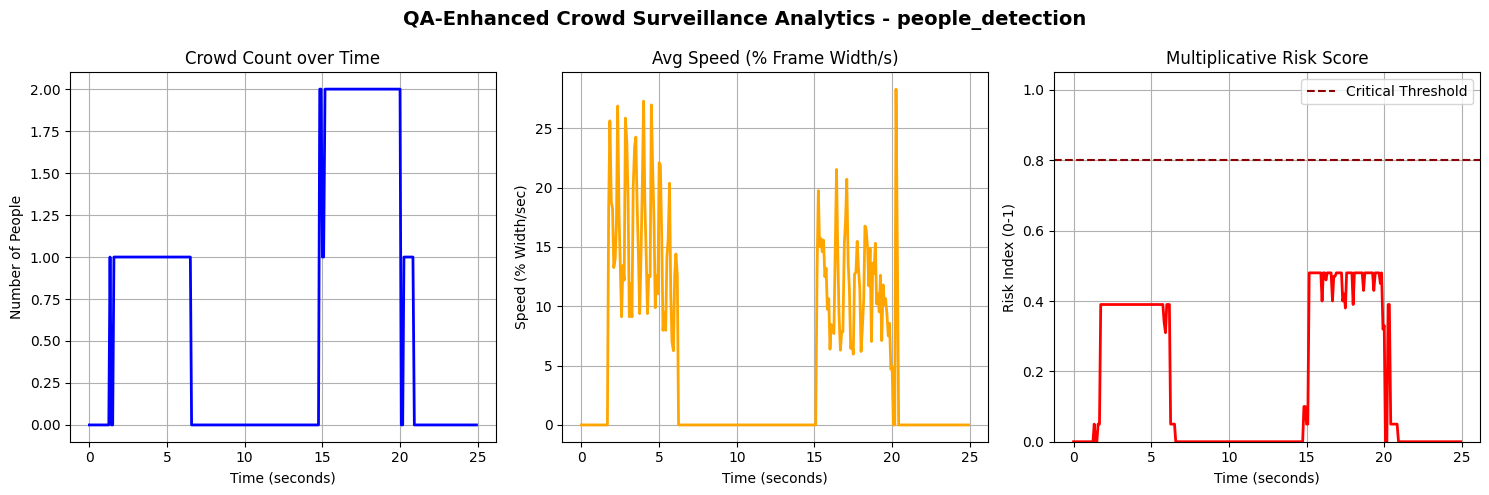

Summary plot saved to ../output\people_detection_summary.png
FINISHED ANALYSIS FOR people_detection.mp4
Total Log Records: 300
Condition Counts:
Detected_Condition
Normal               203
High Motion Alert     97
Name: count, dtype: int64

STARTING ANALYSIS: classroom.mp4
Processing 'classroom.mp4' (1920x1080 @ 30.0 fps). Frames to process: 300


Processed 50/300 frames...


Processed 100/300 frames...


Processed 150/300 frames...


Processed 200/300 frames...


Processed 250/300 frames...


Processed 300/300 frames...
Analysis logs saved to ../output\classroom_log.csv


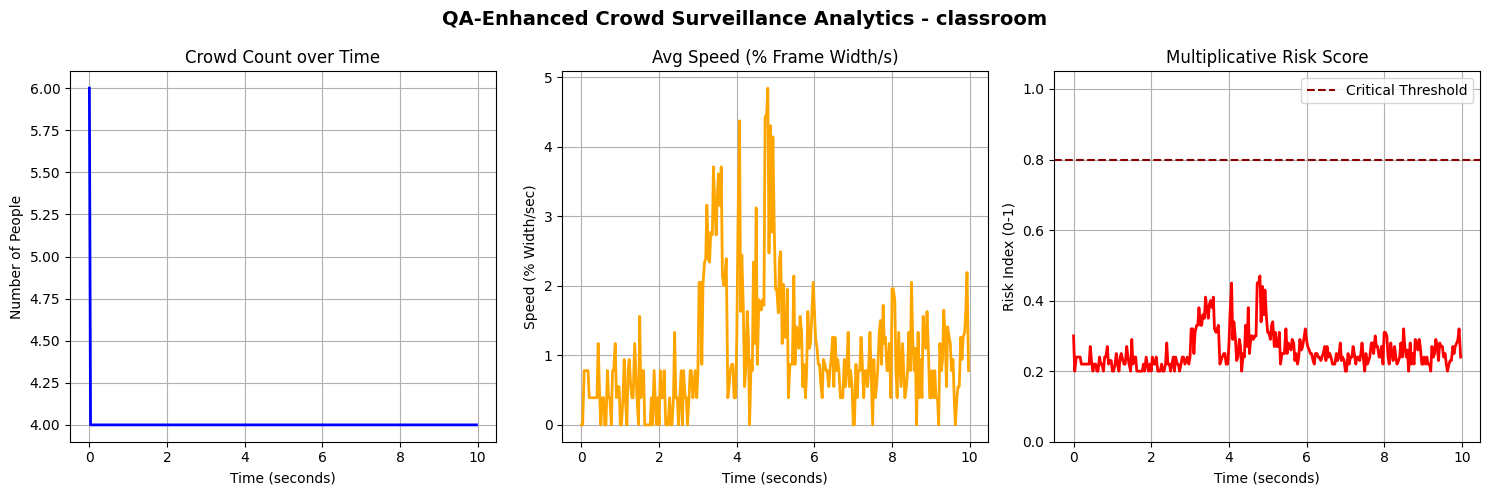

Summary plot saved to ../output\classroom_summary.png
FINISHED ANALYSIS FOR classroom.mp4
Total Log Records: 300
Condition Counts:
Detected_Condition
Normal    300
Name: count, dtype: int64

STARTING ANALYSIS: street_crowd.mp4
Processing 'street_crowd.mp4' (768x432 @ 12.0 fps). Frames to process: 300


Processed 50/300 frames...


Processed 100/300 frames...


Processed 150/300 frames...


Processed 200/300 frames...


Processed 250/300 frames...


Processed 300/300 frames...
Analysis logs saved to ../output\street_crowd_log.csv


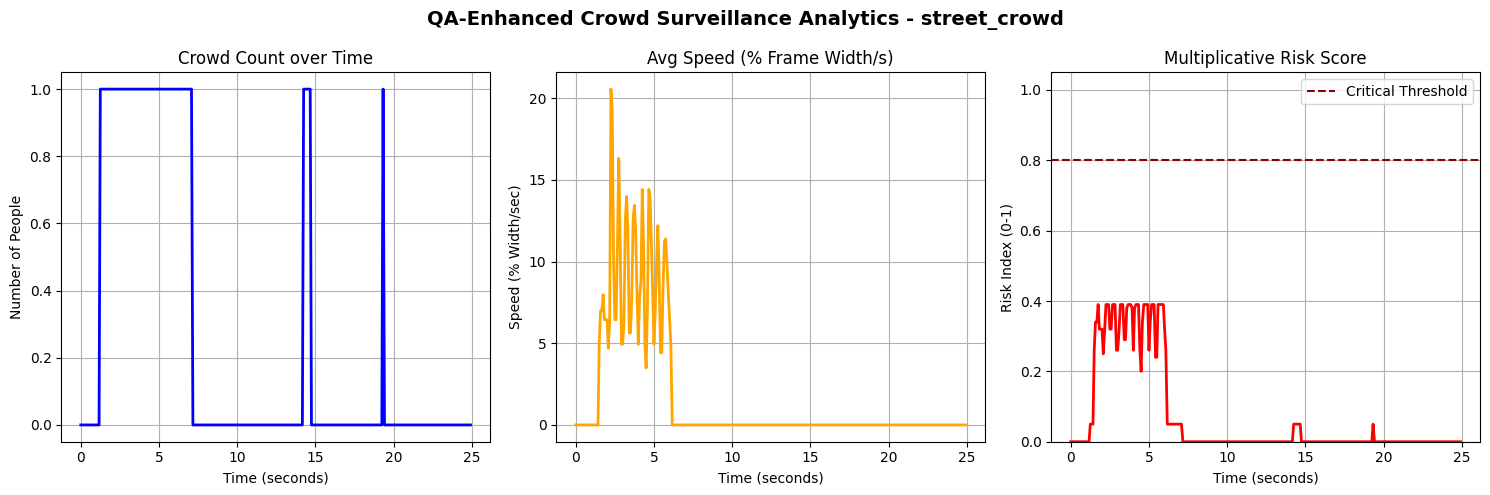

Summary plot saved to ../output\street_crowd_summary.png
FINISHED ANALYSIS FOR street_crowd.mp4
Total Log Records: 300
Condition Counts:
Detected_Condition
Normal               275
High Motion Alert     25
Name: count, dtype: int64


In [4]:
# Instantiate engine and process all 3 videos
engine = CrowdSurveillanceEngine(
    model_path="../Models/yolov8n.pt", 
    density_decay=0.98,
    density_threshold=8, 
    velocity_threshold=0.08  # 8% of frame width per second (equivalent to 5px/f in testing)
)

video_files = ["people_detection.mp4", "classroom.mp4", "street_crowd.mp4"]

for vf in video_files:
    print("\n" + "="*50)
    print(f"STARTING ANALYSIS: {vf}")
    print("="*50)
    try:
        df_logs = engine.process_video(vf, max_frames=300)
        print(f"FINISHED ANALYSIS FOR {vf}")
        print(f"Total Log Records: {len(df_logs)}")
        print(f"Condition Counts:\n{df_logs['Detected_Condition'].value_counts()}")
    except Exception as e:
        print(f"Error processing {vf}: {e}")